# Le Wagon test technique TAs Data Science

Vous disposez de 2h pour compléter ce notebook en expliquant votre démarche et vos observations.
Gérez votre temps comme il vous semble le plus pertinent, la clarté des explication importe autant que la complétion totale du notebook.

**Format de rendu :**
- Lien vers un repository Github public.
- Ce lien devra être envoyé à Laura Mantovi et Agathe Sarran à 12h00.
- Le repository devra contenir votre notebook renommé comme suit : prenom_nom_test_TA_DS.ipynb
- Vous pourrez supprimer ce repository ou le passer en privé à partir de 17h.

Ce notebook doit être éxécutable dans l'environnement virtuel **lewagon** utilisé lors de votre bootcamp.

### Les données

Le fichier **data_weather.csv** comprend des données issues de plusieurs stations météo. Voici un rapide descriptif des colonnes:
- date: date d'enregistrement
- numer_sta: numéro unique de la station
- Latitude: Latitude
- Longitude: Longitude
- Altitude: Altitude
- pmer: pression au niveau de la mer (hpa)
- dd: direction du vent a 10m (sur 360°)
- ff: force du vent a 10m (m/s)
- t: température sous abri (°C)
- u: humidité
- ssfrai: unknown
- rr3: précipitations
- pres: pression à l'altitude de la station  (hpa)
- dd_sin: composante sin de direction du vent
- dd_cos: composante cos de direction du vent

**IMPORTS**

Nous faisons tous les imports dans le première cellule du notebook pour que tout soit centralisé. 
Il s'agit d'une bonne pratique.

In [180]:
import pandas as pd
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
import numpy as np

In [6]:
df = pd.read_csv("data/data_weather.csv",
                 header=0,
                 names=["numer_sta", "latitude", "longitude", "altitude", "pmer", "dd", "t", "u", "ssfrai", "rr3", "pres", "dd_sin", "dd_cos"])

##### Data cleaning

Explorez rapidement les données et nettoyez les colonnes qui en ont besoin.<br>Documentez votre code pour expliquer vos choix.

In [7]:
df

,,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
2010-01-01 00:00:00,7510.0,44.830667,-0.691333,47.0,99050.0,230.0,9.8,9.6,81.0,0.0,0,98410.0,-0.766044,-6.427876e-01
2010-01-01 03:00:00,7510.0,44.830667,-0.691333,47.0,99160.0,250.0,11.8,8.7,87.0,0.0,0,98520.0,-0.939693,-3.420201e-01
2010-01-01 06:00:00,7510.0,44.830667,-0.691333,47.0,99570.0,290.0,5.1,7.6,91.0,0.0,0,98920.0,-0.939693,3.420201e-01
2010-01-01 09:00:00,7510.0,44.830667,-0.691333,47.0,99990.0,310.0,5.7,6.8,92.0,0.0,0,99340.0,-0.766044,6.427876e-01
2010-01-01 12:00:00,7510.0,44.830667,-0.691333,47.0,100350.0,310.0,6.2,6.6,82.0,0.0,0,99690.0,-0.766044,6.427876e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-07-31 09:00:00,7650.0,43.437667,5.216000,9.0,100920.0,310.0,3.2,27.2,58.0,0.0,0,100560.0,-0.766044,6.427876e-01
2021-07-31 12:00:00,7650.0,43.437667,5.216000,9.0,100770.0,270.0,6.1,30.6,49.0,0.0,0,100410.0,-1.000000,-1.836970e-16
2021-07-31 15:00:00,7650.0,43.437667,5.216000,9.0,100680.0,310.0,8.2,30.0,40.0,0.0,0,100320.0,-0.766044,6.427876e-01
2021-07-31 18:00:00,7650.0,43.437667,5.216000,9.0,100750.0,320.0,8.0,27.9,45.0,0.0,0,100390.0,-0.642788,7.660444e-01


In [8]:
df.shape

(505857, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 505857 entries, ('2010-01-01 00:00:00', 7510.0) to ('2021-07-31 21:00:00', 7650.0)
Data columns (total 13 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   numer_sta  505857 non-null  float64
 1   latitude   505857 non-null  float64
 2   longitude  505857 non-null  float64
 3   altitude   505857 non-null  float64
 4   pmer       505857 non-null  float64
 5   dd         505857 non-null  float64
 6   t          505857 non-null  float64
 7   u          505857 non-null  float64
 8   ssfrai     505857 non-null  float64
 9   rr3        505857 non-null  int64  
 10  pres       505791 non-null  float64
 11  dd_sin     505857 non-null  float64
 12  dd_cos     505857 non-null  float64
dtypes: float64(12), int64(1)
memory usage: 53.9+ MB


**DUPLICATES**

Nous allons supprimer les lignes dupliquées.

In [10]:
n_duplicates = df.duplicated().sum()

In [11]:
n_duplicates

89

In [12]:
df_cleaned = df.copy()

In [13]:
df_cleaned = df_cleaned.drop_duplicates()

In [14]:
df_cleaned.shape

(505768, 13)

In [15]:
df.shape[0] - n_duplicates == df_cleaned.shape[0]

True

In [16]:
df_cleaned.duplicated().sum()

0

**MISSING VALUES**

Nous allons regarder s'il y a des valeurs manquantes et, si oui, dans quelle colonne.
Ensuite nous allons utiliser un Imputer s'il n'y a pas trop de valeurs manquantes.

In [17]:
df_cleaned.isnull().sum()

numer_sta     0
latitude      0
longitude     0
altitude      0
pmer          0
dd            0
t             0
u             0
ssfrai        0
rr3           0
pres         65
dd_sin        0
dd_cos        0
dtype: int64

In [18]:
df_cleaned.isnull().sum() / df_cleaned.shape[0]

numer_sta    0.000000
latitude     0.000000
longitude    0.000000
altitude     0.000000
pmer         0.000000
dd           0.000000
t            0.000000
u            0.000000
ssfrai       0.000000
rr3          0.000000
pres         0.000129
dd_sin       0.000000
dd_cos       0.000000
dtype: float64

In [19]:
df_cleaned['pres'].unique()

array([ 98410.,  98520.,  98920., ..., 104070., 104170., 103850.])

In [20]:
df_cleaned['pres'].nunique()

1503

<Axes: >

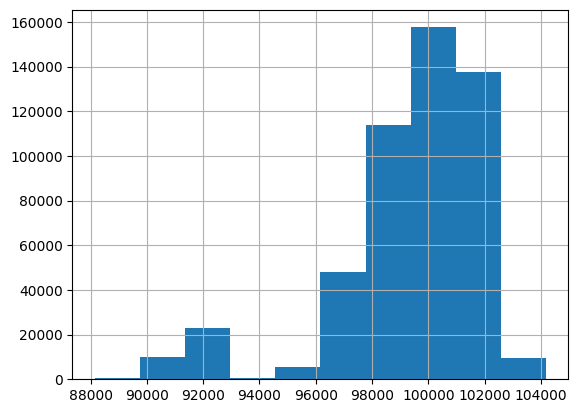

In [21]:
df_cleaned['pres'].hist()

Etant donné qu'il y a très peu de valeurs manquantes en terme de pourcentage dans la colonne pres, nous pouvons imputer en utilsant la stratégie 'mean'.

In [22]:
imputer = SimpleImputer(strategy='mean')

In [23]:
imputer.fit(df_cleaned[['pres']])

SimpleImputer()

In [24]:
imputer.statistics_

array([99359.9170264])

In [25]:
df_cleaned['pres'] = imputer.transform(df_cleaned[['pres']])

In [26]:
df_cleaned.isnull().sum()

numer_sta    0
latitude     0
longitude    0
altitude     0
pmer         0
dd           0
t            0
u            0
ssfrai       0
rr3          0
pres         0
dd_sin       0
dd_cos       0
dtype: int64

##### Data exploration

Quel est le numéro de la station qui a enregistré le plus de précipitations depuis 2010 ?<br>Dans quelle ville se situe-t-elle ?

In [29]:
df_cleaned['rr3'].unique()

array([0, 1])

In [30]:
df_cleaned['rr3'].nunique()

2

In [31]:
df_cleaned['rr3'].value_counts()

rr3
0    496649
1      9119
Name: count, dtype: int64

In [37]:
df_cleaned.groupby('numer_sta')['rr3'].sum().sort_values(ascending=False).head(1)

numer_sta
45.861167    787
Name: rr3, dtype: int64

In [40]:
n_station = df_cleaned.groupby('numer_sta')['rr3'].sum().sort_values(ascending=False).head(1).index[0]

In [41]:
n_station

45.861167

In [44]:
df_cleaned[df_cleaned['numer_sta']== n_station].head(1)

,,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
2010-01-01 00:00:00,7434.0,45.861167,1.175,402.0,99080.0,0.0,0.0,6.1,97.0,0.0,1,94360.0,0.0,1.0


In [46]:
lat_lon_of_station = df_cleaned[df_cleaned['numer_sta']== n_station].head(1)[['latitude','longitude']]

Générez un fichier .csv contenant les moyennes des données météo mensuelles pour la station identifiée.

In [57]:
lat, lon = lat_lon_of_station.iloc[0,0:2]

In [59]:
lat, lon

(1.175, 402.0)

<Axes: >

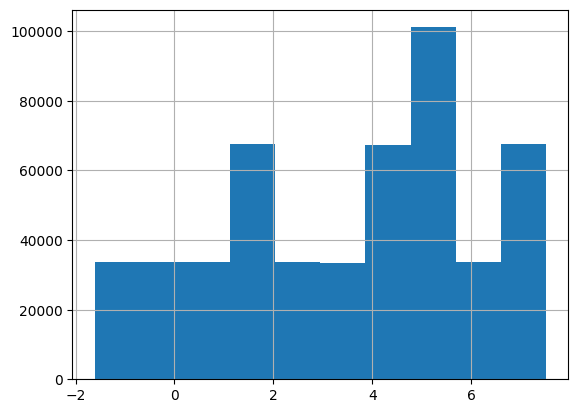

In [63]:
df_cleaned['latitude'].hist()

##### Data visualisation - *optionnel*

Pour chaque station d'enregistrement météo, représentez sur un graphique l'évolution de la moyenne mensuelle de la **température** et de l'**humidité** depuis 2010. <br>*La création des graphiques via l'utilisation d'objets **figure** et **axe** est un plus*.

In [68]:
type(df_cleaned.index)

pandas.core.indexes.multi.MultiIndex

In [70]:
df_cleaned = df_cleaned.reset_index(level=[0])

In [71]:
df_cleaned

,level_0,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
7510.0,2010-01-01 00:00:00,44.830667,-0.691333,47.0,99050.0,230.0,9.8,9.6,81.0,0.0,0,98410.0,-0.766044,-6.427876e-01
7510.0,2010-01-01 03:00:00,44.830667,-0.691333,47.0,99160.0,250.0,11.8,8.7,87.0,0.0,0,98520.0,-0.939693,-3.420201e-01
7510.0,2010-01-01 06:00:00,44.830667,-0.691333,47.0,99570.0,290.0,5.1,7.6,91.0,0.0,0,98920.0,-0.939693,3.420201e-01
7510.0,2010-01-01 09:00:00,44.830667,-0.691333,47.0,99990.0,310.0,5.7,6.8,92.0,0.0,0,99340.0,-0.766044,6.427876e-01
7510.0,2010-01-01 12:00:00,44.830667,-0.691333,47.0,100350.0,310.0,6.2,6.6,82.0,0.0,0,99690.0,-0.766044,6.427876e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7650.0,2021-07-31 09:00:00,43.437667,5.216000,9.0,100920.0,310.0,3.2,27.2,58.0,0.0,0,100560.0,-0.766044,6.427876e-01
7650.0,2021-07-31 12:00:00,43.437667,5.216000,9.0,100770.0,270.0,6.1,30.6,49.0,0.0,0,100410.0,-1.000000,-1.836970e-16
7650.0,2021-07-31 15:00:00,43.437667,5.216000,9.0,100680.0,310.0,8.2,30.0,40.0,0.0,0,100320.0,-0.766044,6.427876e-01
7650.0,2021-07-31 18:00:00,43.437667,5.216000,9.0,100750.0,320.0,8.0,27.9,45.0,0.0,0,100390.0,-0.642788,7.660444e-01


Nous avons passé la colonne date qui était en index, en tant que colonne 'normale' et maintenant nous allons garder seulement la partie 'année-mois' pour faire le groupby.

In [75]:
df_cleaned = df_cleaned.rename(columns={'level_0':'date'})

In [109]:
df_cleaned['date_Y-m'] = df_cleaned['date'].map(lambda x: x[0:7])

In [110]:
df_cleaned['date_Y-m']

7510.0    2010-01
7510.0    2010-01
7510.0    2010-01
7510.0    2010-01
7510.0    2010-01
           ...   
7650.0    2021-07
7650.0    2021-07
7650.0    2021-07
7650.0    2021-07
7650.0    2021-07
Name: date_Y-m, Length: 505768, dtype: object

In [127]:
df_cleaned['numer_sta'].nunique()

15

In [129]:
stations = df_cleaned['numer_sta'].unique()

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

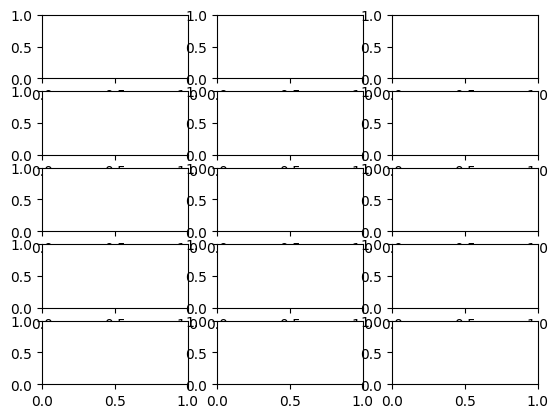

In [133]:
fig, axs = plt.subplots(5, 3)
for i, station in enumerate(stations):
    axs[i].plot(df_cleaned[df_cleaned['numer_sta']== station].groupby('date_Y-m')[['t','u']].mean())

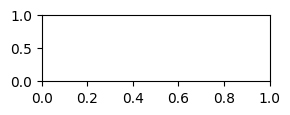

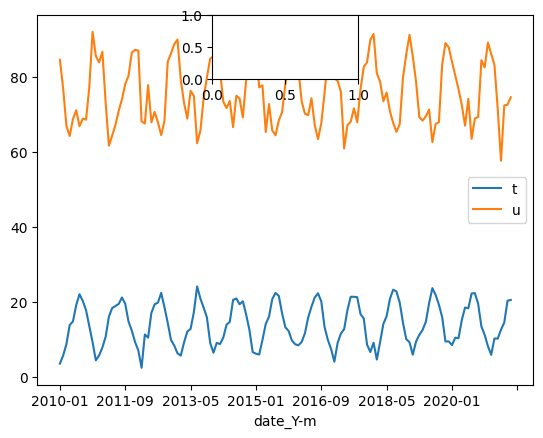

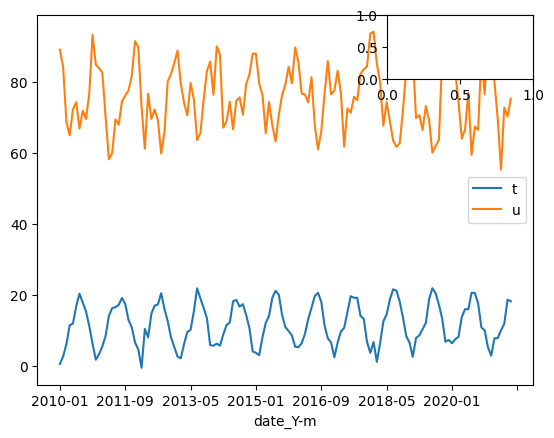

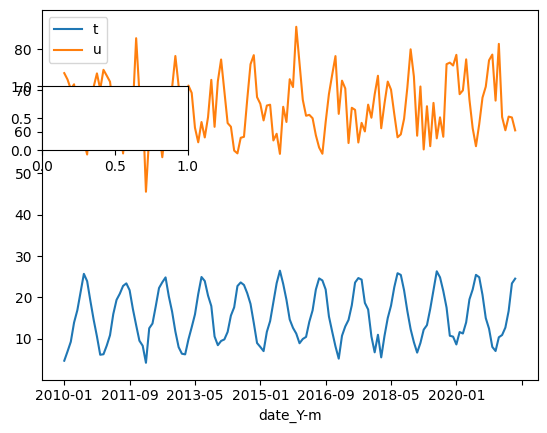

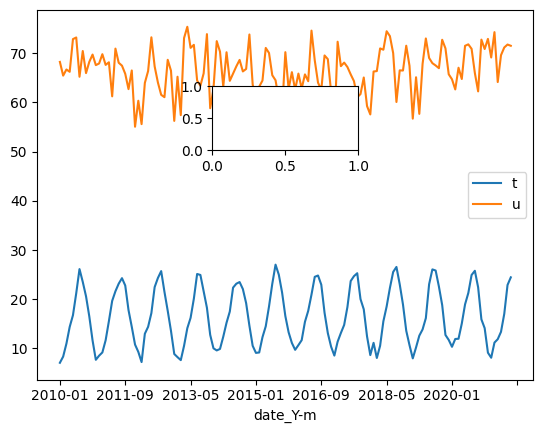

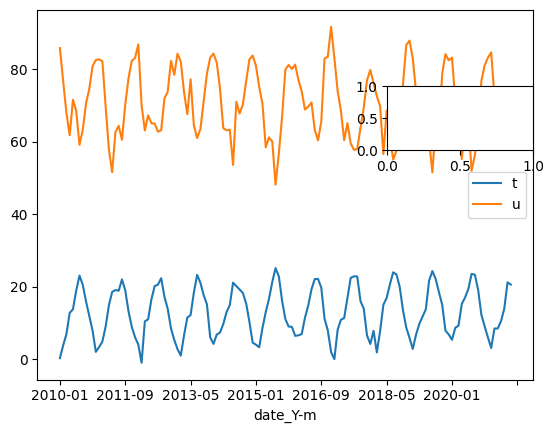

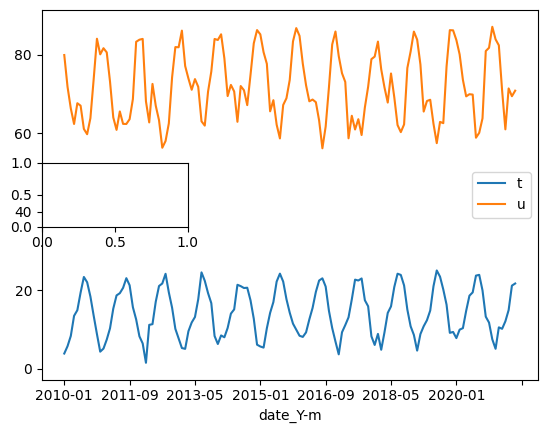

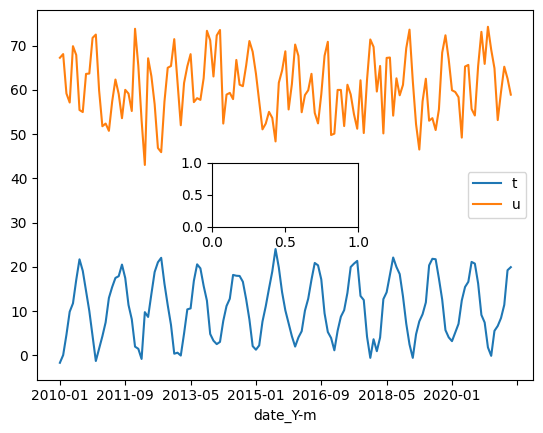

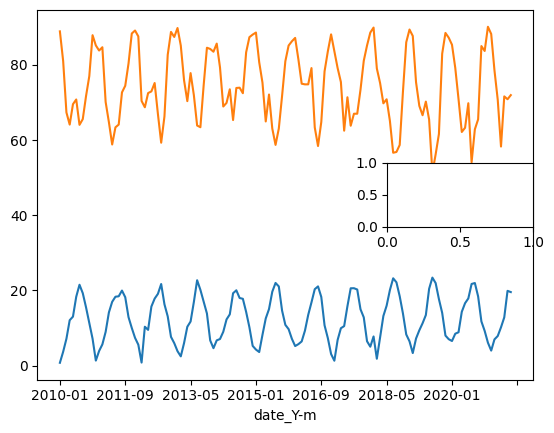

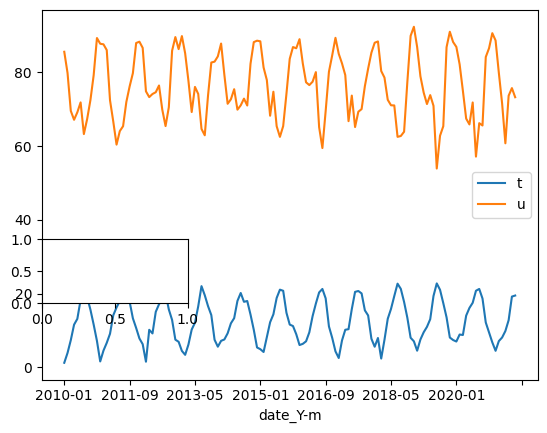

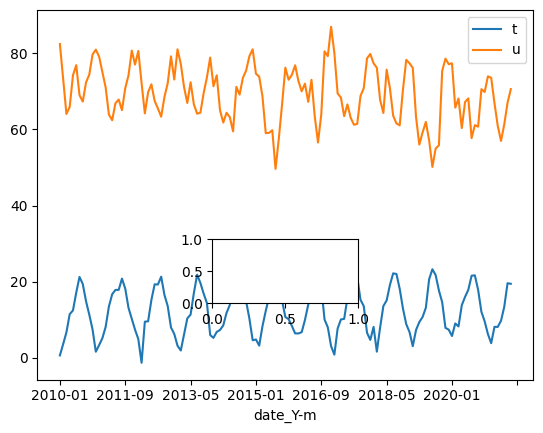

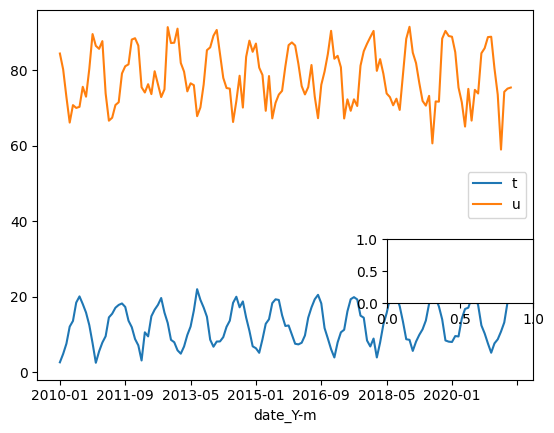

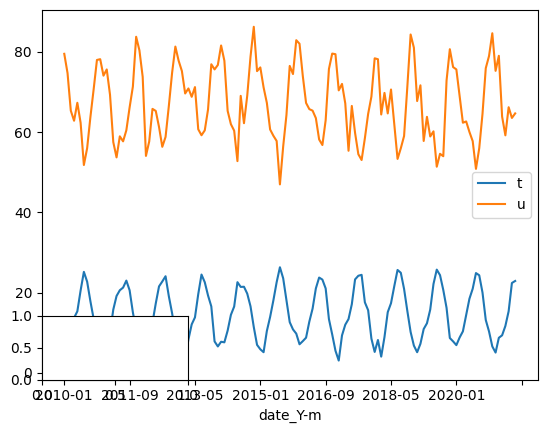

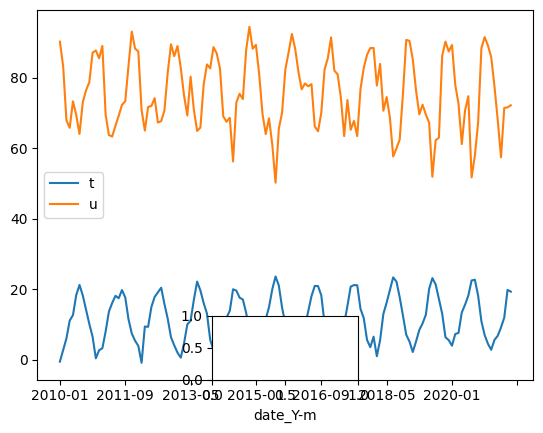

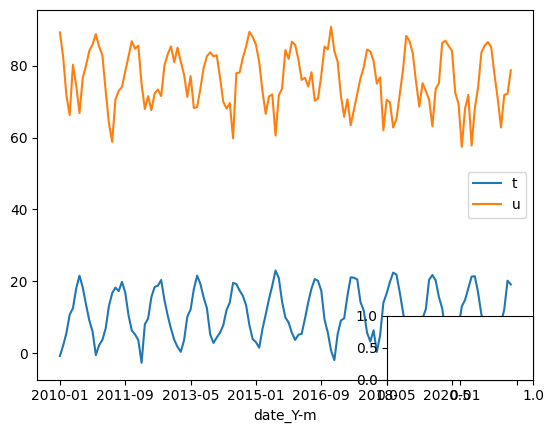

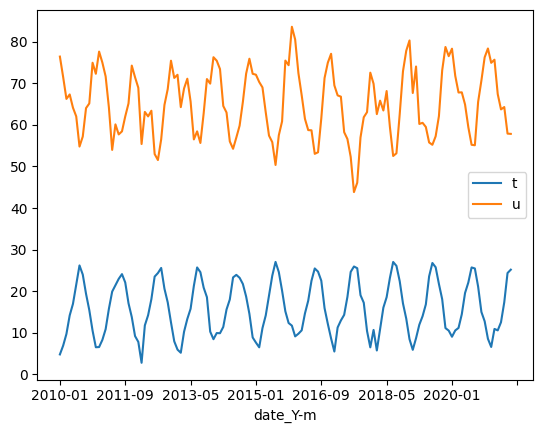

In [142]:
plt.figure(figsize=(10,5))
for i, station in enumerate(stations):
    plt.subplot(5, 3, i+1)
    df_cleaned[df_cleaned['numer_sta']== station].groupby('date_Y-m')[['t','u']].mean().plot()

### Approche Machine Learning

##### Modèles

Après avoir obtenu votre `baseline` explorez librement plusieurs algorithmes de Machine Learning pour prédire un événement pluvieux. Pensez à **expliquer votre méthodologie et les différentes étapes de votre raisonnement.**<br>
- sauvegardez vos scores dans un DataFrame `scores_tracking`
- sauvegardez votre meilleur modèle dans un fichier adapté
- enregistrez les paramètres de votre meilleur modèle dans une variable `best_model_params`

*Une attention particulière sera portée à votre méthode de préparation de données, au choix de(s) métrique(s) de performance, à la robustesse de vos scores et à la prévention de l'overfitting.*

In [159]:
df_cleaned['rr3'].value_counts()

rr3
0    496649
1      9119
Name: count, dtype: int64

In [190]:
df_cleaned['rr3'].value_counts()/df_cleaned.shape[0]

rr3
0    0.98197
1    0.01803
Name: count, dtype: float64

Pour notre baseline, nous allons prédire la valeur la plus fréquente, dans ce cas 0 c'est-à-dire pas de précipitations.

In [160]:
df_cleaned.shape[0]

505768

L'accuracy  vaut (True Positif + True Negatif)/le total 

In [162]:
true_positif = df_cleaned['rr3'].value_counts()[0]

In [163]:
baseline_score = true_positif/df_cleaned.shape[0]

In [164]:
baseline_score

0.9819699941475143

In [173]:
model = LogisticRegression(max_iter=1000)

In [153]:
X = df_cleaned.drop(columns=['numer_sta', 'date', 'date_Y-m'])

In [177]:
X.describe()

/home/andrzej/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
count,505768.000000,505768.000000,5.057680e+05,505768.000000,505768.000000,505768.000000,505768.000000,505768.000000,505768.00000,505768.000000,5.057680e+05,505768.000000
mean,3.451397,193.194004,inf,185.491095,3.417421,13.266489,71.291751,0.000035,0.01803,99359.917026,-7.265803e-02,0.096616
std,2.724455,217.477030,NaN,112.877290,2.350408,7.781545,18.898138,0.003194,0.13306,2597.285995,6.482840e-01,0.751742
min,-1.608833,2.000000,1.059852e-205,0.000000,0.000000,-19.700000,1.000000,0.000000,0.00000,88160.000000,-1.000000e+00,-1.000000
25%,1.175000,26.000000,1.012600e+05,80.000000,1.600000,7.700000,58.000000,0.000000,0.00000,98430.000000,-6.427876e-01,-0.642788
50%,3.963167,151.000000,1.017500e+05,190.000000,3.000000,13.000000,74.000000,0.000000,0.00000,99960.000000,-2.449294e-16,0.173648
75%,5.216000,263.000000,1.022900e+05,280.000000,4.600000,18.700000,87.000000,0.000000,0.00000,101120.000000,5.000000e-01,0.866025
max,7.510000,871.000000,inf,360.000000,23.500000,42.000000,100.000000,0.990000,1.00000,104170.000000,1.000000e+00,1.000000


In [175]:
X

,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
7510.0,-0.691333,47.0,99050.0,230.0,9.8,9.6,81.0,0.0,0,98410.0,-0.766044,-6.427876e-01
7510.0,-0.691333,47.0,99160.0,250.0,11.8,8.7,87.0,0.0,0,98520.0,-0.939693,-3.420201e-01
7510.0,-0.691333,47.0,99570.0,290.0,5.1,7.6,91.0,0.0,0,98920.0,-0.939693,3.420201e-01
7510.0,-0.691333,47.0,99990.0,310.0,5.7,6.8,92.0,0.0,0,99340.0,-0.766044,6.427876e-01
7510.0,-0.691333,47.0,100350.0,310.0,6.2,6.6,82.0,0.0,0,99690.0,-0.766044,6.427876e-01
...,...,...,...,...,...,...,...,...,...,...,...,...
7650.0,5.216000,9.0,100920.0,310.0,3.2,27.2,58.0,0.0,0,100560.0,-0.766044,6.427876e-01
7650.0,5.216000,9.0,100770.0,270.0,6.1,30.6,49.0,0.0,0,100410.0,-1.000000,-1.836970e-16
7650.0,5.216000,9.0,100680.0,310.0,8.2,30.0,40.0,0.0,0,100320.0,-0.766044,6.427876e-01
7650.0,5.216000,9.0,100750.0,320.0,8.0,27.9,45.0,0.0,0,100390.0,-0.642788,7.660444e-01


In [155]:
y = df_cleaned['rr3']

Nous allons scaler toutes les valeurs avec un StandardScaler.
Nous pourrions observer aussi les distributions pour voir si elles sont bien normales (gaussiennes) et les boxplot pour voir s'il n'y pas de outliers.

In [178]:
std_scaler = StandardScaler()

In [183]:
X = X.map(lambda x:0 if x==np.inf else x)

In [184]:
std_scaler.fit(X)

StandardScaler()

In [185]:
X_scaled = std_scaler.transform(X)

In [186]:
cv_result = cross_validate(model, X_scaled, y, scoring=['accuracy'], cv=5)

In [188]:
cv_result['test_accuracy'].mean()

0.999770646736659

In [189]:
cv_result['test_accuracy'].mean() > baseline_score

True

Après avoir généré les valeurs nécessaires à l'affichage de vos **learning curves**, débugguez le code ci-dessous pour produire le graphique attendu.

In [ ]:
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(test_sizes, test_scores_mean, 'Test score')
plt.ylabel('r2 score', fontsize = 14)
plt.xlabel('Test set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend('center')

##### Etes-vous satifait de ces résultats? Comment les expliqueriez-vous ?


L'accuracy obtenue avec un modèle de régression logistique est très grande 99,98% environ.
Ceci n'est pas étonnant étant donné que 98% des observations sont égales à 0 (pas de pluie) donc le modèle prédit presque toujours la valeur la plus fréquante.
On pourrait balancer les données et essayer de voir ce que cela donne.
Une autre approche plus performante serait d'utiliser les Time Series avec un modèle Arima par exemple, en utilisant pour la baseline, la dernière valeur.

### Approche Deep Learning

Tentez d'améliorer vos prédictions grâce à un modèle de Deep Learning et documentez vos choix.